# Retinal Image Alignment Pipeline

Aligns **confocal (iCare)** fundus images to their corresponding **conventional (Topcon)** images.

**Full pipeline per image pair:**
1. Read `.dcm` files using `pydicom`
2. Normalize pixel array to 0-255 (per image)
3. Save normalized images as `.png`
4. Green channel extraction
5. CLAHE enhancement
6. SIFT keypoint detection + Lowe's ratio test
7. RANSAC-based affine estimation (`estimateAffinePartial2D`)
8. Warp confocal onto conventional space

**Input structure:**
```
Data/
└── Train/
    ├── conv/
    │   ├── 1001/
    │   │   ├── 1001_l.dcm
    │   │   └── 1001_r.dcm
    └── conf/
        ├── 1001/
        │   ├── 1001_l.dcm
        │   └── 1001_r.dcm
```

**Output structure:**
```
Data_Aligned/
└── Train/
    ├── conv/
    │   ├── 1001/
    │   │   ├── 1001_l.png   <- normalized, unchanged
    │   │   └── 1001_r.png   <- normalized, unchanged
    └── conf/
        ├── 1001/
        │   ├── 1001_l.png   <- normalized + aligned
        │   └── 1001_r.png   <- normalized + aligned
```

## 1. Imports

In [1]:
import cv2
import numpy as np
import pydicom
import shutil
import gc
import multiprocessing
from concurrent.futures import ProcessPoolExecutor, as_completed
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

## 2. Define Paths

Set the input and output root directories here.  
Change `DATA_ROOT` if your folder is located elsewhere.

In [2]:
# Input
DATA_ROOT    = Path("/home/prem/dlri/pytorch-CycleGAN-and-pix2pix/datasets/new/Data/First batch")
CONV_IN_DIR  = DATA_ROOT / "topcon_maestro2/Anomalous"
CONF_IN_DIR  = DATA_ROOT / "icare_eidon/Anomalous"

# Output
OUT_ROOT     = Path("datasets/new_aligned/Data/First batch")
CONV_OUT_DIR = OUT_ROOT / "conv"
CONF_OUT_DIR = OUT_ROOT / "conf"

print(f"Input  conv : {CONV_IN_DIR}")
print(f"Input  conf : {CONF_IN_DIR}")
print(f"Output conv : {CONV_OUT_DIR}")
print(f"Output conf : {CONF_OUT_DIR}")

Input  conv : /home/prem/dlri/pytorch-CycleGAN-and-pix2pix/datasets/new/Data/First batch/topcon_maestro2/Anomalous
Input  conf : /home/prem/dlri/pytorch-CycleGAN-and-pix2pix/datasets/new/Data/First batch/icare_eidon/Anomalous
Output conv : datasets/new_aligned/Data/First batch/conv
Output conf : datasets/new_aligned/Data/First batch/conf


## 3. DICOM Reader

Reads a `.dcm` file and returns a normalized **uint8 numpy array** (0-255).  

**Why per-image normalization is fine here:**  
SIFT detects keypoints based on local gradients, not absolute pixel intensity.  
So normalizing each image independently does not affect alignment quality.

In [3]:
def read_dicom_as_uint8(dcm_path: Path) -> np.ndarray:
    """
    Reads a DICOM file and returns a normalized uint8 numpy array.

    Parameters
    ----------
    dcm_path : Path -- path to the .dcm file

    Returns
    -------
    img_uint8 : np.ndarray -- normalized image in uint8 (H, W) or (H, W, 3)
    """
    ds         = pydicom.dcmread(str(dcm_path))
    pixels     = ds.pixel_array.astype(np.float32)

    # Per-image normalization to 0-255
    pmin, pmax = pixels.min(), pixels.max()
    del ds
    if pmax - pmin == 0:
        res = np.zeros_like(pixels, dtype=np.uint8)
        del pixels
        return res

    normalized = (pixels - pmin) / (pmax - pmin) * 255
    res = normalized.astype(np.uint8)
    del pixels, normalized
    return res

## 4. Alignment Function

Takes two uint8 numpy arrays (conv and conf),  
returns the aligned confocal array.

**Steps inside:**
1. Extract green channel (or use as-is if grayscale)
2. Apply CLAHE (contrast enhancement)
3. Detect SIFT keypoints + descriptors
4. Match with BFMatcher + Lowe's ratio test (threshold = 0.7)
5. Estimate partial affine transform with RANSAC
6. Warp confocal onto conventional coordinate space

In [4]:
def align_images(img_conv: np.ndarray, img_conf: np.ndarray):
    """
    Aligns confocal image to conventional image.

    Parameters
    ----------
    img_conv : np.ndarray -- conventional image (uint8)
    img_conf : np.ndarray -- confocal image (uint8)

    Returns
    -------
    aligned_conf : np.ndarray -- aligned confocal (same shape as img_conv)
    M            : np.ndarray -- 2x3 affine transform matrix
    inliers      : int        -- number of RANSAC inliers
    good_matches : int        -- matches after Lowe's ratio test
    """
    # Handle grayscale vs color -- extract green channel if color
    if img_conv.ndim == 3:
        gr_conv = img_conv[:, :, 1]
        gr_conf = img_conf[:, :, 1]
    else:
        gr_conv = img_conv
        gr_conf = img_conf

    # CLAHE enhancement
    clahe       = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    gr_conv_enh = clahe.apply(gr_conv)
    gr_conf_enh = clahe.apply(gr_conf)

    # SIFT keypoints
    sift                     = cv2.SIFT_create(nfeatures=1000)
    kp_conv, desc_conv       = sift.detectAndCompute(gr_conv_enh, None)
    kp_conf, desc_conf       = sift.detectAndCompute(gr_conf_enh, None)

    # Match + Lowe's ratio test
    bf      = cv2.BFMatcher()
    matches = bf.knnMatch(desc_conv, desc_conf, k=2)
    good    = [m for m, n in matches if m.distance < 0.7 * n.distance]

    if len(good) < 4:
        raise ValueError(f"Not enough good matches: {len(good)}")

    # RANSAC affine estimation
    dst_pts = np.float32([kp_conv[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    src_pts = np.float32([kp_conf[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    M, mask = cv2.estimateAffinePartial2D(
        src_pts, dst_pts,
        method=cv2.RANSAC,
        ransacReprojThreshold=5
    )

    if M is None:
        raise ValueError("RANSAC failed to find a valid transform")

    # Warp confocal onto conventional space
    h, w         = gr_conv.shape
    aligned_conf = cv2.warpAffine(img_conf, M, (w, h))

    n_good = len(good)
    n_inliers = int(mask.sum())
    try:
        del gr_conv, gr_conf, gr_conv_enh, gr_conf_enh, kp_conv, kp_conf, desc_conv, desc_conf, matches, good, dst_pts, src_pts
    except:
        pass

    return aligned_conf, M, n_inliers, n_good

## 5. Run Alignment on All Image Pairs

For each patient ID:
- Reads `.dcm` files using `read_dicom_as_uint8()`
- Aligns conf to conv using `align_images()`
- Saves both as `.png` (replacing `.dcm` extension) to `Data_Aligned/`

Skipped files are logged at the end -- they do **not** crash the pipeline.

In [5]:
def _cleanup_output_folders(patient_id):
    """Remove the patient's output folders from both conv and conf output dirs."""
    for out_dir in [CONV_OUT_DIR, CONF_OUT_DIR]:
        folder = out_dir / patient_id
        if folder.exists():
            shutil.rmtree(folder)


def process_patient(id_folder_str):
    id_folder = Path(id_folder_str)
    patient_id = id_folder.name
    conf_id_folder = CONF_IN_DIR / patient_id

    local_flagged = []
    local_success = 0

    if not conf_id_folder.exists():
        return local_success, [(f"{patient_id}/{patient_id}", "No matching conf ID folder")]

    (CONV_OUT_DIR / patient_id).mkdir(parents=True, exist_ok=True)
    (CONF_OUT_DIR / patient_id).mkdir(parents=True, exist_ok=True)

    conf_left_paths = sorted(conf_id_folder.glob("*_l_*.dcm"))
    conf_right_paths = sorted(conf_id_folder.glob("*_r_*.dcm"))

    for conv_path in sorted(id_folder.glob("*.dcm")):
        filename = conv_path.stem + ".png"
        img_conv = None
        img_conf = None
        aligned_conf = None
        mask = None
        mask_3ch = None

        is_left = "_l_" in conv_path.name.lower()
        is_right = "_r_" in conv_path.name.lower()

        if is_left:
            conf_paths = conf_left_paths
        elif is_right:
            conf_paths = conf_right_paths
        else:
            conf_paths = []

        if not conf_paths:
            local_flagged.append((f"{patient_id}/{conv_path.name}", "No matching conf image"))
            _cleanup_output_folders(patient_id)
            continue

        conf_path = conf_paths[0]

        try:
            img_conv = read_dicom_as_uint8(conv_path)
            img_conf = read_dicom_as_uint8(conf_path)
            aligned_conf, M, inliers, n_matches = align_images(img_conv, img_conf)

            h, w = img_conv.shape[:2]
            mask = np.zeros((h, w), dtype=np.uint8)
            cv2.circle(mask, (w // 2, h // 2), min(h, w) // 2 - 50, 255, -1)
            if aligned_conf.ndim == 3:
                mask_3ch = np.repeat(mask[:, :, None], aligned_conf.shape[2], axis=2)
                aligned_conf = cv2.bitwise_and(aligned_conf, mask_3ch)
            else:
                aligned_conf = cv2.bitwise_and(aligned_conf, mask)

            from PIL import Image

            Image.fromarray(aligned_conf).save(str(CONF_OUT_DIR / patient_id / filename))
            Image.fromarray(img_conv).save(str(CONV_OUT_DIR / patient_id / filename))

            local_success += 1
        except Exception as e:
            local_flagged.append((f"{patient_id}/{conv_path.name}", str(e)))
            _cleanup_output_folders(patient_id)
        finally:
            del img_conv, img_conf, aligned_conf, mask, mask_3ch
            gc.collect()

    return local_success, local_flagged


In [6]:
import os
import threading

FLAGGED_PATH = OUT_ROOT / "flagged.txt"
OUT_ROOT.mkdir(parents=True, exist_ok=True)
_flag_lock = threading.Lock()


def _append_to_flagged(entries):
    """Thread-safe append of flagged entries to flagged.txt."""
    if not entries:
        return
    with _flag_lock:
        with open(FLAGGED_PATH, "a") as f:
            for label, reason in entries:
                f.write(f"{label}  ->  {reason}\n")


FLAGGED_PATH.write_text("")

id_folders = sorted([f for f in CONV_IN_DIR.iterdir() if f.is_dir()])
print(f"Found {len(id_folders)} patient ID folders.\n")

# Tune down parallelism to avoid RAM spikes in notebook sessions.
MAX_WORKERS = min(2, os.cpu_count() or 1)
PRINT_EVERY = 10

success = 0
flagged_count = 0

with ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(process_patient, str(folder)): folder.name for folder in id_folders}
    for idx, future in enumerate(
        tqdm(as_completed(futures), total=len(futures), desc="Aligning patients"),
        start=1,
    ):
        s, fl = future.result()
        success += s
        if fl:
            flagged_count += len(fl)
            _append_to_flagged(fl)

        if idx % PRINT_EVERY == 0 or idx == len(id_folders):
            gc.collect()

print(f"\n{'='*50}")
print(f"  Successfully aligned : {success}")
print(f"  Flagged              : {flagged_count}")
print(f"  Flagged log          : {FLAGGED_PATH}")
print(f"  Workers used         : {MAX_WORKERS}")
print(f"{'='*50}")

if flagged_count:
    preview_lines = FLAGGED_PATH.read_text().splitlines()[:10]
    print("\nFirst flagged entries (see flagged.txt for the full list):")
    for line in preview_lines:
        print(f"  X  {line}")


Found 39 patient ID folders.



Aligning patients: 100%|██████████| 39/39 [05:00<00:00,  7.71s/it]


  Successfully aligned : 72
  Flagged              : 21
  Flagged log          : datasets/new_aligned/Data/First batch/flagged.txt
  Workers used         : 2

First flagged entries (see flagged.txt for the full list):
  X  1025/1025_maestro2_3d_macula_cfp_r_2.16.840.1.114517.10.5.1.4.907063120230831165213.2.1.dcm  ->  Not enough good matches: 0
  X  1025/1025_maestro2_3d_macula_cfp_r_2.16.840.1.114517.10.5.1.4.907063120230831165514.2.1.dcm  ->  [Errno 2] No such file or directory: 'datasets/new_aligned/Data/First batch/conf/1025/1025_maestro2_3d_macula_cfp_r_2.16.840.1.114517.10.5.1.4.907063120230831165514.2.1.png'
  X  1056/1056_maestro2_3d_macula_cfp_r_2.16.840.1.114517.10.5.1.4.907063120231103162511.2.1.dcm  ->  Not enough good matches: 3
  X  1069/1069_maestro2_3d_macula_cfp_l_2.16.840.1.114517.10.5.1.4.907063120231127143616.2.1.dcm  ->  No matching conf image
  X  1069/1069_maestro2_3d_macula_cfp_r_2.16.840.1.114517.10.5.1.4.907063120231127143532.2.1.dcm  ->  [Errno 2] No such fi

In [7]:
import os
print(f"CPU count: {os.cpu_count()}")
print("Notebook run uses the MAX_WORKERS value from the alignment cell above.")


CPU count: 9
Notebook run uses the MAX_WORKERS value from the alignment cell above.


## 6. Verify Output

Prints a table showing file counts per patient ID for both conv and conf outputs.

In [8]:
print(f"{'ID':<20} {'conv (saved)':<20} {'conf (aligned)'}")
print("-" * 55)

for id_folder in sorted(CONV_OUT_DIR.iterdir()):
    patient_id = id_folder.name
    conv_count = len(list((CONV_OUT_DIR / patient_id).glob("*.png")))
    conf_count = len(list((CONF_OUT_DIR / patient_id).glob("*.png")))
    print(f"{patient_id:<20} {conv_count:<20} {conf_count}")

ID                   conv (saved)         conf (aligned)
-------------------------------------------------------
1002                 3                    3
1030                 3                    3
1033                 0                    0
1038                 3                    3
1043                 4                    4
1045                 2                    2
1046                 2                    2
1054                 3                    3
1060                 2                    2
1063                 3                    3
1065                 2                    2
1066                 3                    3
1075                 2                    2
1077                 4                    4
1092                 1                    1
1093                 0                    0
1102                 3                    3
1109                 2                    2
1114                 3                    3
1118                 3                    3
1121   

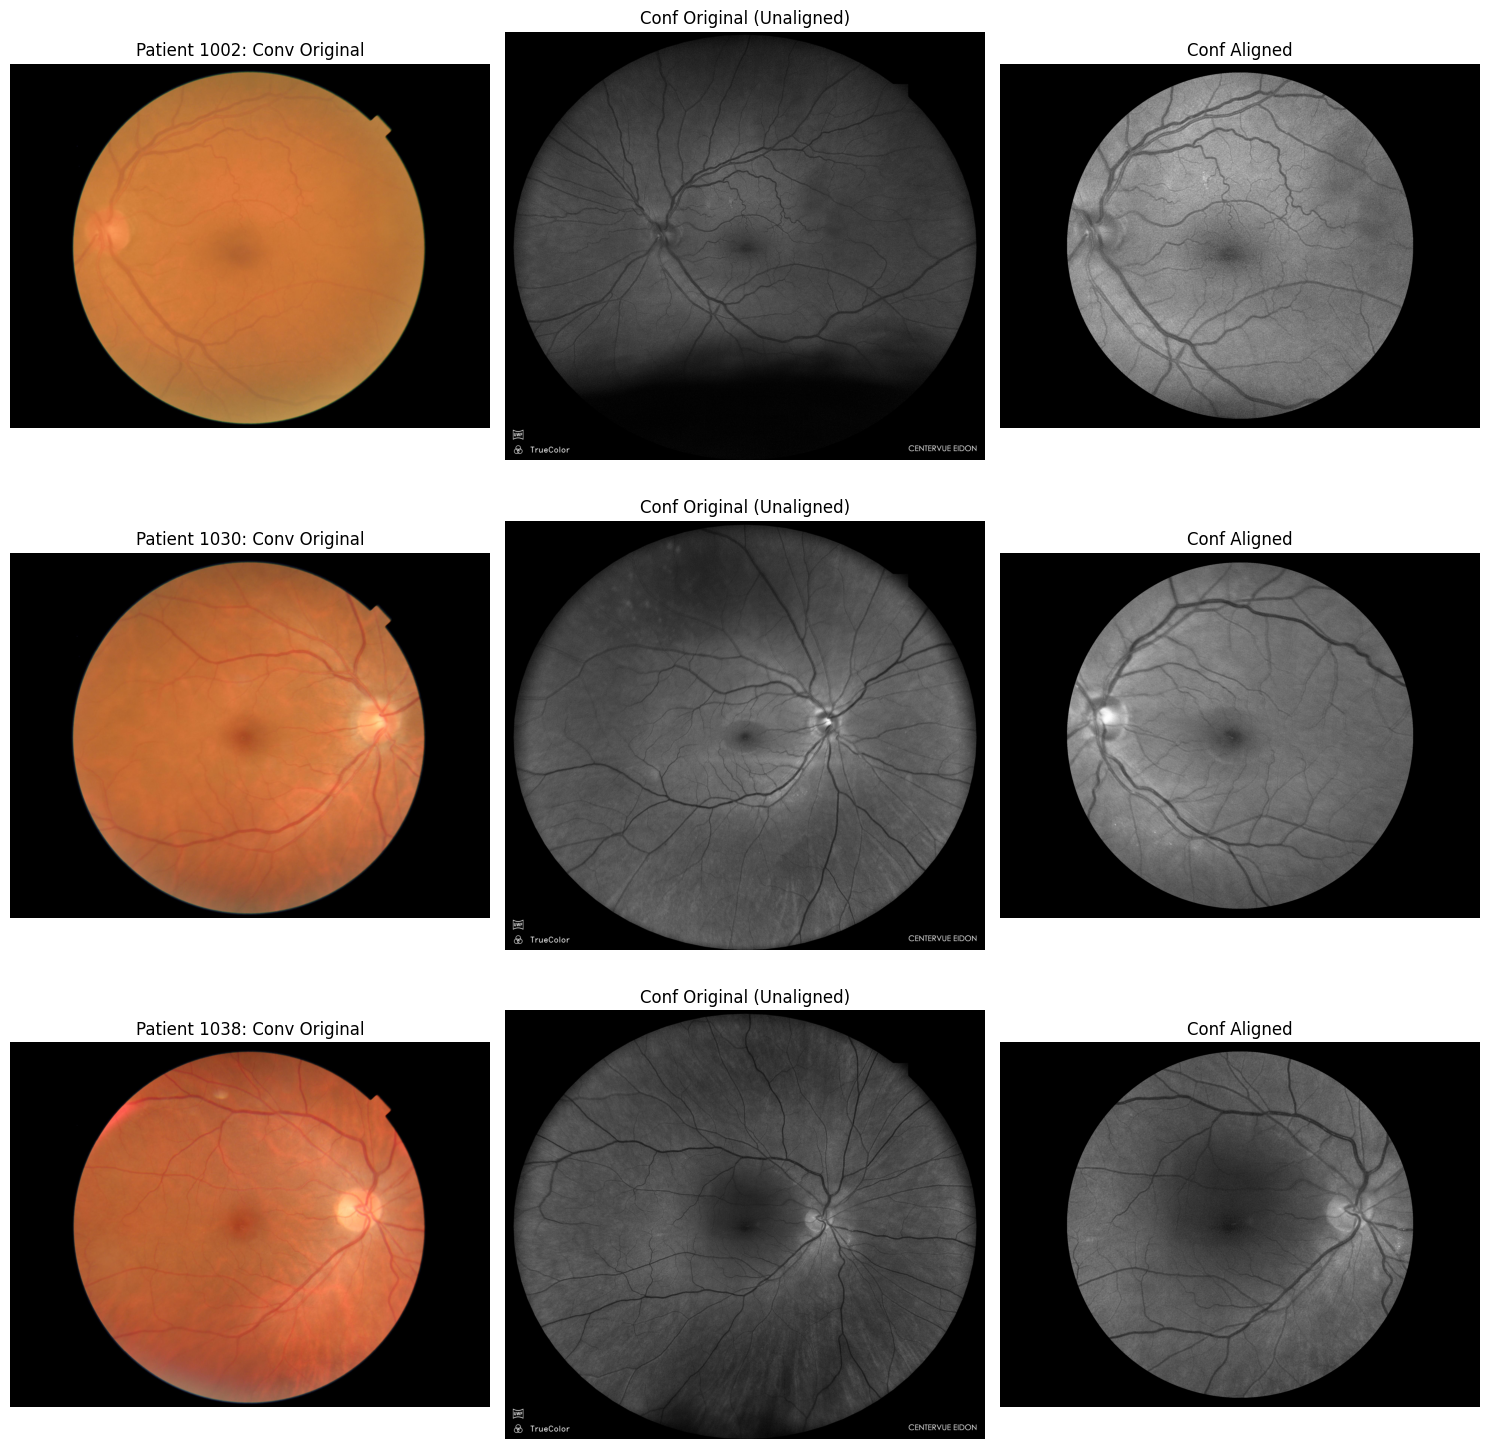

In [9]:
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

# Plot before and after for up to 3 anomalous pairs that successfully aligned
sample_patients = []
for f in sorted(CONV_IN_DIR.iterdir()):
    if f.is_dir() and list((CONF_OUT_DIR / f.name).glob("*.png")):
        sample_patients.append(f.name)
        if len(sample_patients) == 3:
            break

if not sample_patients:
    print("No successfully aligned images to plot.")
else:
    fig, axes = plt.subplots(len(sample_patients), 3, figsize=(15, 5 * len(sample_patients)))
    if len(sample_patients) == 1:
        axes = [axes]

    for i, patient in enumerate(sample_patients):
        conv_img = None
        conf_img = None
        aligned_img = None

        conv_orig_list = list((CONV_IN_DIR / patient).glob("*.dcm"))
        if not conv_orig_list:
            continue
        conv_orig = conv_orig_list[0]

        is_left = "_l_" in conv_orig.name.lower()
        conf_orig_pattern = "*_l_*.dcm" if is_left else "*_r_*.dcm"
        conf_orig_list = list((CONF_IN_DIR / patient).glob(conf_orig_pattern))
        if not conf_orig_list:
            continue
        conf_orig = conf_orig_list[0]

        conf_aligned = list((CONF_OUT_DIR / patient).glob("*.png"))[0]

        conv_img = read_dicom_as_uint8(conv_orig)
        conf_img = read_dicom_as_uint8(conf_orig)
        if conf_img.ndim == 3:
            conf_img = conf_img[:, :, 1]

        aligned_img = cv2.imread(str(conf_aligned), cv2.IMREAD_GRAYSCALE)

        axes[i][0].imshow(conv_img, cmap="gray")
        axes[i][0].set_title(f"Patient {patient}: Conv Original")
        axes[i][0].axis("off")

        axes[i][1].imshow(conf_img, cmap="gray")
        axes[i][1].set_title("Conf Original (Unaligned)")
        axes[i][1].axis("off")

        axes[i][2].imshow(aligned_img, cmap="gray")
        axes[i][2].set_title("Conf Aligned")
        axes[i][2].axis("off")

        del conv_img, conf_img, aligned_img

    plt.tight_layout()
    plt.show()
    plt.close(fig)
